## Télécharger, Extraire et Préparer le Jeu de Données

In [1]:
# Créer le répertoire 'Data' s'il n'existe pas
!mkdir -p Data

In [2]:
# Télécharger le fichier zip du jeu de données
!wget -O DogsVsCats.zip https://github.com/devtlv/Datasets-GEN-AI-Bootcamp/raw/refs/heads/main/Week%206/W6D5/Dogs%20vs%20Cats.zip

--2026-06-19 10:56:03--  https://github.com/devtlv/Datasets-GEN-AI-Bootcamp/raw/refs/heads/main/Week%206/W6D5/Dogs%20vs%20Cats.zip
Resolving github.com (github.com)... 140.82.116.3
Connecting to github.com (github.com)|140.82.116.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://media.githubusercontent.com/media/devtlv/Datasets-GEN-AI-Bootcamp/refs/heads/main/Week%206/W6D5/Dogs%20vs%20Cats.zip [following]
--2026-06-19 10:56:04--  https://media.githubusercontent.com/media/devtlv/Datasets-GEN-AI-Bootcamp/refs/heads/main/Week%206/W6D5/Dogs%20vs%20Cats.zip
Resolving media.githubusercontent.com (media.githubusercontent.com)... 185.199.108.133, 185.199.110.133, 185.199.109.133, ...
Connecting to media.githubusercontent.com (media.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 856265363 (817M) [application/zip]
Saving to: ‘DogsVsCats.zip’

DogsVsCats.zip      100%[===================>] 816

In [3]:
# Dézipper le fichier téléchargé. En supposant qu'il s'extraira dans un dossier nommé 'Dogs vs Cats'
!unzip DogsVsCats.zip

Le flux de sortie a été tronqué et ne contient que les 5000 dernières lignes.
  inflating: train/train/dog.5499.jpg  
  inflating: train/train/dog.55.jpg  
  inflating: train/train/dog.550.jpg  
  inflating: train/train/dog.5500.jpg  
  inflating: train/train/dog.5501.jpg  
  inflating: train/train/dog.5502.jpg  
  inflating: train/train/dog.5503.jpg  
  inflating: train/train/dog.5504.jpg  
  inflating: train/train/dog.5505.jpg  
  inflating: train/train/dog.5506.jpg  
  inflating: train/train/dog.5507.jpg  
  inflating: train/train/dog.5508.jpg  
  inflating: train/train/dog.5509.jpg  
  inflating: train/train/dog.551.jpg  
  inflating: train/train/dog.5510.jpg  
  inflating: train/train/dog.5511.jpg  
  inflating: train/train/dog.5512.jpg  
  inflating: train/train/dog.5513.jpg  
  inflating: train/train/dog.5514.jpg  
  inflating: train/train/dog.5515.jpg  
  inflating: train/train/dog.5516.jpg  
  inflating: train/train/dog.5517.jpg  
  inflating: train/train/dog.5518.jpg  
  infl

In [4]:
# Créer le répertoire 'cats_dogs' et déplacer les dossiers 'train' et 'test' extraits à l'intérieur
!mkdir cats_dogs
!mv train test cats_dogs/

In [5]:
# Déplacer le dossier 'cats_dogs' dans le répertoire 'Data'
!mv cats_dogs Data/

In [6]:
# Vérifier le contenu du répertoire 'Data/cats_dogs'
!ls Data/cats_dogs

test  train


### Chargement des Données avec Augmentation d'Images

In [7]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Définir les répertoires d'entraînement et de test corrects
TRAINING_BASE_DIR = "Data/cats_dogs/train/train"
TESTING_BASE_DIR = "Data/cats_dogs/test/test"

# Définir les paramètres des images
IMG_WIDTH = 150
IMG_HEIGHT = 150
BATCH_SIZE = 32

In [8]:
# Créer les sous-répertoires 'cats' et 'dogs' dans le répertoire d'entraînement pour le générateur
!mkdir -p {TRAINING_BASE_DIR}/cats
!mkdir -p {TRAINING_BASE_DIR}/dogs

# Déplacer les images de chats et de chiens dans leurs répertoires respectifs
# Les images du dossier de test sont déjà bien organisées
!mv {TRAINING_BASE_DIR}/cat*.jpg {TRAINING_BASE_DIR}/cats/
!mv {TRAINING_BASE_DIR}/dog*.jpg {TRAINING_BASE_DIR}/dogs/

# Générateur de données pour l'entraînement avec augmentation et split de validation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2 # 20% des données d'entraînement pour la validation
)

train_generator = train_datagen.flow_from_directory(
    TRAINING_BASE_DIR,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training' # Spécifie l'ensemble d'entraînement
)

val_generator = train_datagen.flow_from_directory(
    TRAINING_BASE_DIR,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation' # Spécifie l'ensemble de validation
)

Found 20000 images belonging to 2 classes.
Found 5000 images belonging to 2 classes.


In [9]:
import os
import pandas as pd

# Générateur de données pour le test (uniquement avec remise à échelle, sans augmentation et sans étiquettes)
test_datagen = ImageDataGenerator(rescale=1./255)

# Lister les fichiers dans le répertoire de test
test_filenames = os.listdir(TESTING_BASE_DIR)
# Créer un DataFrame pour le générateur de test
test_df = pd.DataFrame(test_filenames, columns=['filename'])

test_generator = test_datagen.flow_from_dataframe(
    test_df,
    directory=TESTING_BASE_DIR,
    x_col='filename',
    y_col=None, # Pas d'étiquettes pour les données de test non étiquetées
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode=None, # Important pour les prédictions non étiquetées
    shuffle=False # Important pour l'ordre des prédictions
)

Found 12500 validated image filenames.


Les générateurs `train_generator`, `val_generator` et `test_generator` sont maintenant tous configurés pour charger et prétraiter vos images. Les données d'entraînement ont été réorganisées et le générateur de test utilise `flow_from_dataframe` pour une compatibilité correcte avec la structure de vos fichiers.

In [10]:
import os, math, re, random
from glob import glob
from pathlib import Path
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split

np.random.seed(42); tf.random.set_seed(42)

# Chemins - à changer si nécessaire
DATA_ROOT = Path("Data/cats_dogs") # Correction du chemin pour correspondre à notre structure 'Data/cats_dogs'
train_dir = (DATA_ROOT / "train" / "train") if (DATA_ROOT / "train" / "train").exists() else (DATA_ROOT / "train")
test_dir  = (DATA_ROOT / "test"  / "test")  if (DATA_ROOT / "test"  / "test").exists()  else (DATA_ROOT / "test")

IMG_HEIGHT, IMG_WIDTH = 180, 180
batch_size = 32
seed = 1337

# Construire des DataFrames à partir des dossiers
def build_df_from_folder(folder: Path, labeled: bool=True):
    exts = ('*.jpg','*.jpeg','*.png','*.bmp')
    files = []
    for ex in exts:
        files.extend(glob(str(folder / '**' / ex), recursive=True))
    if not files:
        raise FileNotFoundError(f"Aucune image trouvée sous {folder}")
    rows = []
    for f in files:
        if labeled:
            name = Path(f).name.lower()
            parent = Path(f).parent.name.lower()
            if parent in {"cat","cats"}:
                label = "cat"
            elif parent in {"dog","dogs"}:
                label = "dog"
            else:
                if re.search(r'(^|[^a-z])cat([^a-z]|$)', name): label = "cat"
                elif re.search(r'(^|[^a-z])dog([^a-z]|$)', name): label = "dog"
                else:
                    continue
            rows.append({"filepath": f, "label": label})
        else:
            rows.append({"filepath": f})
    return pd.DataFrame(rows)

df_train_full = build_df_from_folder(train_dir, labeled=True)
df_test_full  = build_df_from_folder(test_dir,  labeled=False)

# Séparation entraînement/validation
df_tr, df_val = train_test_split(
    df_train_full, test_size=0.2, stratify=df_train_full["label"], random_state=seed
)

# Générateurs
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=45,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.5,
    horizontal_flip=True,
)
val_gen = ImageDataGenerator(rescale=1./255)
test_gen = ImageDataGenerator(rescale=1./255)

train_flow = train_gen.flow_from_dataframe(
    df_tr, x_col="filepath", y_col="label",
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    class_mode="binary", batch_size=batch_size,
    shuffle=True, seed=seed, validate_filenames=False
)
val_flow = val_gen.flow_from_dataframe(
    df_val, x_col="filepath", y_col="label",
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    class_mode="binary", batch_size=batch_size,
    shuffle=False, validate_filenames=False
)
# Test non étiqueté pour l'inférence uniquement
test_flow = test_gen.flow_from_dataframe(
    df_test_full, x_col="filepath", y_col=None,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    class_mode=None, batch_size=batch_size,
    shuffle=False, validate_filenames=False
)

print({"train": train_flow.samples, "val": val_flow.samples, "test": test_flow.samples,
       "class_indices": train_flow.class_indices})

Found 20000 non-validated image filenames belonging to 2 classes.
Found 5000 non-validated image filenames belonging to 2 classes.
Found 12500 non-validated image filenames.
{'train': 20000, 'val': 5000, 'test': 12500, 'class_indices': {'cat': 0, 'dog': 1}}


Pourquoi cela est important : vous standardisez la taille de l’image et les valeurs des pixels pour stabiliser les dégradés. L’augmentation expose le modèle à des transformations plausibles et réduit le surapprentissage. Une répartition de validation fournit un signal impartial pour guider les choix du modèle et de l’entraînement. Un itérateur de test non étiqueté vous permet de générer des prédictions pour soumission ou relecture manuelle.

Point d’apprentissage : Gardez la validation intacte par une augmentation qui modifie les étiquettes ou la distribution. Entraînement d’augmentation uniquement.

## Inspecter les données

Nous allons maintenant examiner la distribution des classes dans notre jeu de données d'entraînement et visualiser quelques images pour comprendre la variabilité visuelle.

In [11]:
import numpy as np

# Obtenir le nombre total d'images d'entraînement par classe
class_counts = np.bincount(train_flow.labels)
class_names = list(train_flow.class_indices.keys())

print("Nombre total d'images d'entraînement par classe :")
for i, count in enumerate(class_counts):
    print(f"- {class_names[i].capitalize()} : {count} images")

# Vérifier l'équilibre des classes
if np.all(class_counts == class_counts[0]):
    print("\nLes classes sont équilibrées.")
else:
    print("\nLes classes sont déséquilibrées.")

# Afficher les sources potentielles de variabilité visuelle
print("\nSources potentielles de variabilité visuelle :\n")
print("1.  **Pose :** Les animaux peuvent être dans différentes positions (assis, debout, couchés, en mouvement).")
print("2.  **Échelle :** Les animaux peuvent apparaître de tailles différentes dans l'image (proches ou éloignés de la caméra).")
print("3.  **Éclairage :** Les images peuvent avoir des conditions d'éclairage variées (jour, nuit, lumière artificielle, ombres).")
print("4.  **Arrière-plan :** Les arrière-plans peuvent être très divers (intérieurs, extérieurs, différents types de végétation, objets).")
print("5.  **Couleur et Race :** La couleur du pelage et la race des animaux varient considérablement, même au sein d'une même classe.")
print("6.  **Obstruction :** Des parties des animaux peuvent être cachées par des objets ou d'autres éléments.")

Nombre total d'images d'entraînement par classe :
- Cat : 10000 images
- Dog : 10000 images

Les classes sont équilibrées.

Sources potentielles de variabilité visuelle :

1.  **Pose :** Les animaux peuvent être dans différentes positions (assis, debout, couchés, en mouvement).
2.  **Échelle :** Les animaux peuvent apparaître de tailles différentes dans l'image (proches ou éloignés de la caméra).
3.  **Éclairage :** Les images peuvent avoir des conditions d'éclairage variées (jour, nuit, lumière artificielle, ombres).
4.  **Arrière-plan :** Les arrière-plans peuvent être très divers (intérieurs, extérieurs, différents types de végétation, objets).
5.  **Couleur et Race :** La couleur du pelage et la race des animaux varient considérablement, même au sein d'une même classe.
6.  **Obstruction :** Des parties des animaux peuvent être cachées par des objets ou d'autres éléments.


## Visualisation des images d'entraînement

Nous allons maintenant tracer une petite grille d'images d'entraînement et les annoter avec leurs étiquettes pour mieux comprendre les caractéristiques visuelles. Cela nous aidera à identifier les indices qui pourraient aider le modèle à distinguer les chats des chiens.

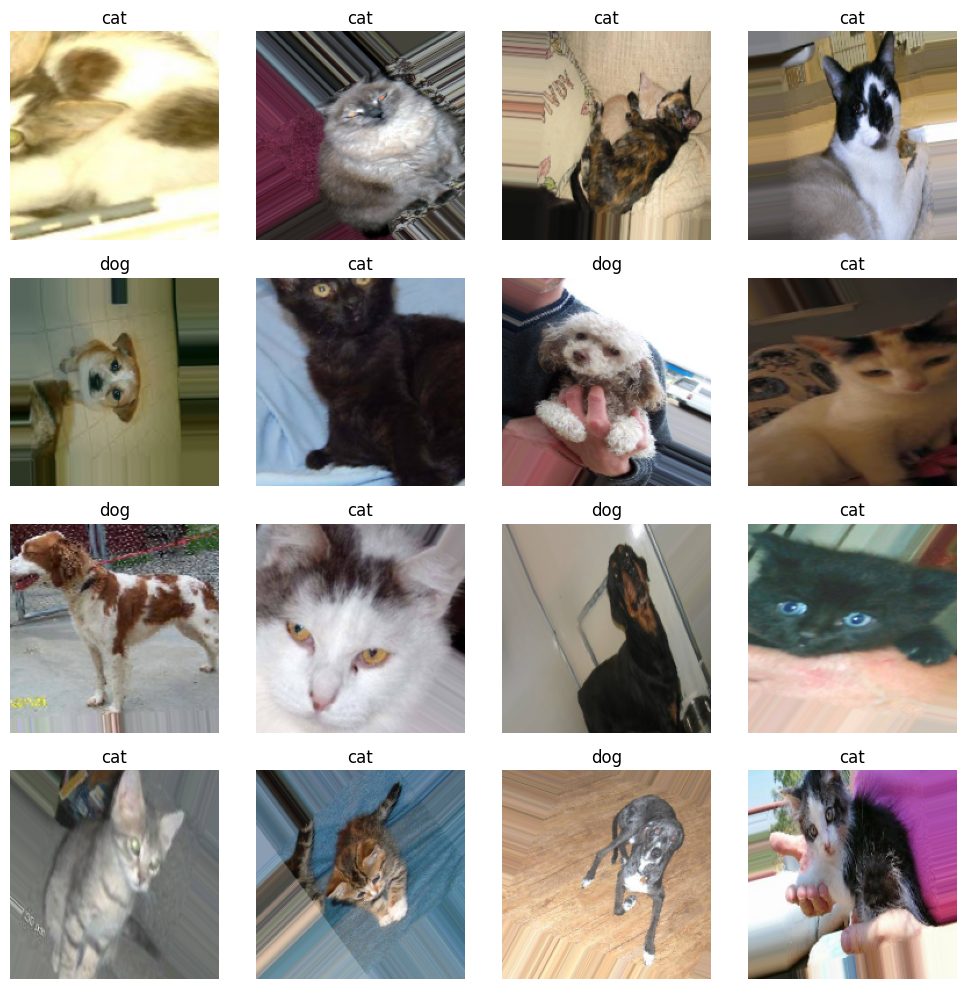

In [12]:
import matplotlib.pyplot as plt

# Récupérer un lot d'images et d'étiquettes du générateur d'entraînement
images, labels = next(train_flow)

# Définir la taille de la grille (par exemple, 4x4)
num_images_to_display = 16
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
axes = axes.flatten()

# Récupérer l'inverse du dictionnaire class_indices pour mapper les entiers aux noms de classe
label_map = {v: k for k, v in train_flow.class_indices.items()}

for i in range(num_images_to_display):
    # Assurez-vous que l'image est dans le bon format (0-1 ou 0-255)
    img = images[i]
    if img.max() > 1.0: # Si les images sont en 0-255, les diviser par 255
        img = img / 255.0

    axes[i].imshow(img)
    # L'étiquette est un flottant (0.0 ou 1.0), le convertir en int pour le mapping
    title = label_map[int(labels[i])]
    axes[i].set_title(title)
    axes[i].axis('off')

plt.tight_layout()
plt.show()


### Indices visuels pour distinguer les chats des chiens

En observant les images, voici quelques indices visuels qui pourraient aider un modèle à distinguer les chats des chiens :

1.  **Forme du museau et du crâne :** Les chiens ont souvent des museaux plus longs et plus carrés, tandis que les chats ont tendance à avoir des museaux plus petits et un crâne plus arrondi.
2.  **Yeux :** Les yeux des chats sont souvent plus grands et plus fendus, avec des pupilles qui peuvent être verticales. Les yeux des chiens sont généralement plus ronds.
3.  **Oreilles :** Les oreilles des chiens sont très variées (dressées, tombantes, de différentes tailles), tandis que celles des chats sont souvent plus pointues et dressées.
4.  **Corpulence et structure corporelle :** Les chats ont une silhouette plus élégante et souple, tandis que les chiens présentent une plus grande diversité de tailles et de corpulences, allant des petits aux très grands.
5.  **Pelage et Moustache :** Bien que les deux puissent avoir des pelages variés, la texture et la densité peuvent différer. Les moustaches des chats sont souvent plus proéminentes et plus raides.
6.  **Comportement et Expression :** Bien que difficile à capturer sur une seule image, les expressions faciales et les postures peuvent varier. Les chats peuvent avoir une expression plus "féline" ou stoïque, tandis que les chiens peuvent apparaître plus joyeux ou expressifs.

Ces observations sont cruciales car elles guident la compréhension des caractéristiques que le modèle devra apprendre à reconnaître.

## Définir l'architecture du modèle

Nous allons construire un réseau de neurones convolutionnel (CNN) séquentiel pour classer les images de chats et de chiens. L'architecture sera conçue pour extraire efficacement les caractéristiques des images tout en prévenant le surapprentissage.

### Architecture CNN Proposée :

1.  **Blocs Convolutionnels :** Le modèle commencera par plusieurs blocs convolutionnels. Chaque bloc sera composé d'une couche `Conv2D` suivie d'une fonction d'activation `ReLU` (Rectified Linear Unit), puis d'une couche `MaxPooling2D`. Nous augmenterons le nombre de filtres dans chaque bloc successif pour permettre au modèle d'apprendre des caractéristiques de plus en plus complexes à mesure que la profondeur du réseau augmente. Par exemple, nous pourrions commencer avec 32 filtres pour le premier bloc, puis passer à 64, et enfin 128 filtres avec des tailles de filtre de (3,3) pour capturer des motifs locaux comme les bords et les textures. Les couches de convolution sont fondamentales car elles balayent l'image pour détecter ces motifs, qui sont des indices visuels essentiels pour la classification.

2.  **Placement de MaxPooling :** Une couche `MaxPooling2D` de taille (2,2) sera placée après chaque couche `Conv2D` activée. Son rôle est de réduire les dimensions spatiales de la carte de caractéristiques, ce qui diminue le nombre de paramètres et de calculs dans le réseau. Cela aide également à rendre le modèle plus robuste aux petites translations dans l'image (invariance translationnelle), signifiant que la détection d'une caractéristique est moins sensible à sa position exacte dans l'image. Cette réduction dimensionnelle est cruciale pour que le modèle puisse gérer la variabilité de pose et d'échelle observée dans les données.

3.  **Utilisation du Dropout :** Une ou plusieurs couches `Dropout` seront insérées après les blocs convolutionnels et avant les couches denses finales. Le Dropout est une technique de régularisation où, pendant l'entraînement, un pourcentage aléatoire de neurones est "désactivé" (leurs sorties sont mises à zéro) à chaque étape. Cela empêche les neurones de co-s'adapter excessivement et de devenir trop dépendants les uns des autres, forçant ainsi le réseau à apprendre des représentations plus robustes et moins spécifiques aux données d'entraînement. Cela réduit considérablement le risque de surapprentissage, particulièrement important avec la grande variabilité des images de chats et de chiens.

4.  **Couches Finales Denses :** Après l'extraction des caractéristiques par les couches convolutionnelles et le Flatten pour aplatir les données en un vecteur unidimensionnel, nous aurons une ou plusieurs couches `Dense` (fully connected) avec activation `ReLU`. Ces couches interprètent les caractéristiques apprises pour prendre une décision de classification. La couche de sortie finale sera une couche `Dense` avec **une seule unité** et une fonction d'activation `sigmoid`. Puisque nous traitons un problème de classification binaire (chat ou chien), la fonction sigmoïde est le choix approprié car elle produit une sortie entre 0 et 1, que l'on peut interpréter comme la probabilité que l'image appartienne à la classe positive (par exemple, "chien").

### Pertinence de l'architecture :

*   **Convolutions et Pooling :** Ces couches capturent des motifs locaux (bords, textures) et fournissent une invariance translationnelle, ce qui est essentiel étant donné la diversité des positions et des éclairages des animaux.
*   **Dropout :** Il est crucial pour la régularisation et pour empêcher le surapprentissage sur un dataset potentiellement complexe où les images peuvent varier considérablement.
*   **Couche de sortie Sigmoïde :** C'est le choix correct pour la classification binaire, permettant de prédire directement la probabilité d'appartenance à l'une des deux classes.

Cette architecture est un point de départ solide pour résoudre notre problème de classification d'images de chats et de chiens.

## 4. Choisir la configuration d’optimisation

Pour entraîner notre modèle CNN, nous devons définir une stratégie d'optimisation robuste qui permet une convergence rapide et stable, tout en prévenant le surapprentissage.

### Configuration d'Optimisation Proposée :

1.  **Optimiseur : Adam**
    *   **Justification :** L'optimiseur `Adam` (Adaptive Moment Estimation) est un choix populaire et souvent performant pour l'entraînement des réseaux de neurones profonds. Il combine les avantages des algorithateurs `Adagrad` et `RMSProp`, en adaptant le taux d'apprentissage pour chaque paramètre individuellement et en utilisant des moyennes mobiles des gradients et des carrés des gradients. Cela lui permet de gérer efficacement les gradients creux et bruyants, et conduit généralement à une convergence plus rapide et plus stable que les méthodes de descente de gradient stochastique (SGD) classiques, en particulier sur des problèmes d'images complexes.

2.  **Taux d'apprentissage initial : 0.001 (1e-3)**
    *   **Justification :** Un taux d'apprentissage initial de 0.001 est une valeur communément utilisée et considérée comme un bon point de départ pour de nombreux modèles de réseaux de neurones, en particulier avec l'optimiseur Adam. Un taux trop élevé peut entraîner des oscillations et empêcher la convergence, tandis qu'un taux trop faible peut rendre l'entraînement excessivement lent. Cette valeur permet généralement un bon compromis entre la vitesse d'apprentissage et la stabilité.

3.  **Taille du lot (Batch Size) : 32**
    *   **Justification :** La taille du lot a été définie à 32, comme lors de la création des générateurs de données. Ce choix est un compromis courant entre efficacité computationnelle et performance de l'entraînement. Des lots plus petits (par exemple 16 ou 32) introduisent plus de bruit dans les mises à jour des gradients, ce qui peut aider à échapper aux minima locaux et à généraliser davantage. Des lots plus grands (par exemple 64 ou 128) peuvent accélérer le calcul par itération mais risquent de converger vers des minima plus "plats" et d'être moins efficaces pour la généralisation. Une taille de 32 est également bien adaptée aux contraintes de mémoire GPU/CPU pour ce type de tâche.

4.  **EarlyStopping (Arrêt Précoce)**
    *   **Justification :** `EarlyStopping` est une technique de régularisation cruciale qui permet d'arrêter l'entraînement lorsque la performance du modèle sur l'ensemble de validation cesse de s'améliorer. Nous allons surveiller la `val_loss` (perte de validation) et spécifier un `patience` (par exemple, 10-15 époques). Si la perte de validation n'a pas diminué pendant `patience` époques consécutives, l'entraînement s'arrêtera. Cela prévient efficacement le surapprentissage en garantissant que le modèle ne continue pas à apprendre des détails spécifiques aux données d'entraînement au détriment de sa capacité à généraliser sur des données non vues.

5.  **ReduceLROnPlateau (Réduire le Taux d'Apprentissage sur Plateau)** (Optionnel)
    *   **Justification :** Cette technique est un complément puissant à l'arrêt précoce. Si la perte de validation cesse de s'améliorer pendant un certain nombre d'époques (`patience` plus court que pour `EarlyStopping`), `ReduceLROnPlateau` réduira le taux d'apprentissage d'un facteur (par exemple, 0.1). Cela permet au modèle de sortir des plateaux de convergence et de faire des ajustements plus fins dans l'espace des paramètres, améliorant potentiellement la performance finale. Il est souvent utilisé pour affiner le modèle une fois que le taux d'apprentissage initial a fait la majeure partie du travail.

### Point d'apprentissage :
Il est important de surveiller à la fois la perte et la précision durant l'entraînement. La **perte (loss)** est souvent une métrique plus douce et plus sensible aux petites améliorations ou dégradations de la qualité des probabilités prédites. La **précision (accuracy)**, bien qu'intuitive, peut être trompeuse, surtout en cas de déséquilibre de classe (bien que ce ne soit pas le cas ici). Dans notre contexte de classification binaire avec une sortie sigmoïde, l'entropie croisée binaire est la fonction de perte correcte et une métrique fiable à surveiller.

## 5. Entraîner le modèle

Nous allons maintenant implémenter et entraîner le modèle CNN que nous avons défini. Nous commencerons par un entraînement sans stratégies d'arrêt précoce pour visualiser la dynamique d'apprentissage et de surapprentissage.

In [13]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Définition de l'architecture du modèle
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dropout(0.5), # Ajout de Dropout pour la régularisation
    layers.Dense(512, activation='relu'),
    layers.Dense(1, activation='sigmoid') # Couche de sortie pour classification binaire
])

# Compilation du modèle
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Afficher le résumé du modèle
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 87, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 41, 41, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 18, 18, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 9, 9, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 10368)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10368)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     5,308,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,550,273 (21.17 MB)

 Trainable params: 5,550,273 (21.17 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 231s 369ms/step - accuracy: 0.5429 - loss: 0.6882 - val_accuracy: 0.5426 - val_loss: 0.6864
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 224s 358ms/step - accuracy: 0.5701 - loss: 0.6793 - val_accuracy: 0.5940 - val_loss: 0.6620
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 224s 358ms/step - accuracy: 0.6280 - loss: 0.6437 - val_accuracy: 0.6852 - val_loss: 0.5941
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 224s 359ms/step - accuracy: 0.6754 - loss: 0.6014 - val_accuracy: 0.7206 - val_loss: 0.5463
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 224s 358ms/step - accuracy: 0.7061 - loss: 0.5698 - val_accuracy: 0.7326 - val_loss: 0.5317


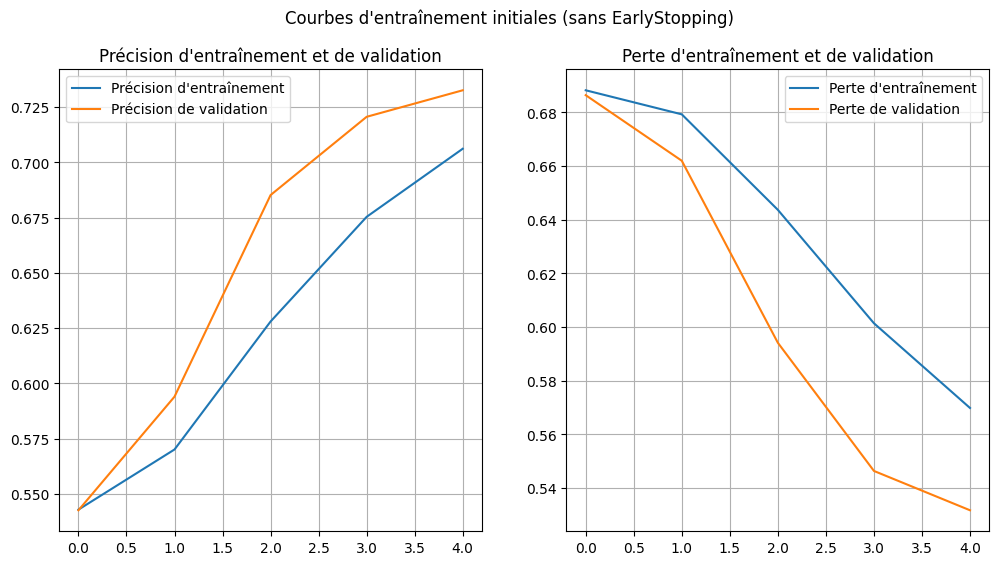

In [15]:
import matplotlib.pyplot as plt

# Entraînement initial pour un nombre fixe d'époques (sans EarlyStopping pour observer le surapprentissage)
epochs = 5 # Un nombre d'époques suffisamment grand pour potentiellement voir le surapprentissage

history_fixed_epochs = model.fit(
    train_flow,
    epochs=epochs,
    validation_data=val_flow
)

# Fonction pour tracer les courbes d'apprentissage
def plot_training_history(history, title="Courbes d'entraînement et de validation"):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Précision d\'entraînement')
    plt.plot(epochs_range, val_acc, label='Précision de validation')
    plt.title('Précision d\'entraînement et de validation')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Perte d\'entraînement')
    plt.plot(epochs_range, val_loss, label='Perte de validation')
    plt.title('Perte d\'entraînement et de validation')
    plt.legend()
    plt.grid(True)

    plt.suptitle(title)
    plt.show()

# Tracer l'historique d'entraînement initial
plot_training_history(history_fixed_epochs, "Courbes d'entraînement initiales (sans EarlyStopping)")

### Détection et atténuation du surapprentissage

**Comment détecter le surapprentissage à partir des courbes :**

Le surapprentissage (overfitting) se manifeste sur les courbes d'entraînement et de validation par une divergence croissante entre les performances sur l'ensemble d'entraînement et l'ensemble de validation. Plus précisément :

*   **Sur la courbe de précision :** La précision d'entraînement continue d'augmenter (ou reste élevée), tandis que la précision de validation stagne ou commence à diminuer. Cela indique que le modèle apprend les particularités du jeu d'entraînement mais perd sa capacité à généraliser sur des données non vues.
*   **Sur la courbe de perte :** La perte d'entraînement continue de diminuer, tandis que la perte de validation diminue d'abord, puis stagne ou commence à augmenter. Une augmentation de la perte de validation est un indicateur fort de surapprentissage, car le modèle devient de plus en plus confiant dans ses prédictions pour les données d'entraînement, mais ces prédictions deviennent de moins en moins précises pour les données de validation.

**Changements pour atténuer le surapprentissage :**

Pour atténuer le surapprentissage, plusieurs stratégies peuvent être employées :

1.  **Augmentation des données (Data Augmentation) :** C'est déjà en place avec notre `ImageDataGenerator`. En appliquant des transformations aléatoires aux images d'entraînement (rotation, zoom, décalage, retournement horizontal), nous augmentons artificiellement la taille et la diversité du jeu d'entraînement, ce qui rend le modèle plus robuste et moins susceptible de mémoriser des exemples spécifiques.

2.  **Dropout :** Nous avons inclus des couches `Dropout` dans notre architecture. Le dropout désactive aléatoirement un pourcentage de neurones pendant l'entraînement, forçant le réseau à apprendre des représentations plus redondantes et moins dépendantes d'un ensemble spécifique de neurones.

3.  **Régularisation L1/L2 :** Ces techniques ajoutent une pénalité à la fonction de perte pour les poids importants du modèle, encourageant le modèle à utiliser des poids plus petits et plus dispersés.

4.  **Arrêt Précoce (EarlyStopping) :** C'est l'une des méthodes les plus efficaces et les plus simples. Au lieu d'entraîner le modèle pour un nombre fixe d'époques, nous surveillons la performance sur l'ensemble de validation et arrêtons l'entraînement dès que cette performance cesse de s'améliorer (par exemple, la perte de validation n'a pas diminué pendant un certain nombre d'époques consécutives). Cela garantit que le modèle ne s'entraîne pas au-delà du point où il généralise le mieux.

5.  **Réduction du Taux d'Apprentissage sur Plateau (ReduceLROnPlateau) :** Cette technique, souvent utilisée avec `EarlyStopping`, réduit dynamiquement le taux d'apprentissage lorsque la performance du modèle sur l'ensemble de validation stagne. Un taux d'apprentissage plus faible permet au modèle de faire des ajustements plus fins et de sortir des minimums locaux potentiels.

6.  **Réduction de la complexité du modèle :** Si le modèle est trop grand (trop de couches ou trop de neurones par couche) par rapport à la taille et à la complexité des données, il peut facilement surapprendre. Réduire le nombre de paramètres peut aider.

Dans la prochaine étape, nous réentraînerons le modèle en utilisant les techniques `EarlyStopping` et `ReduceLROnPlateau` pour combattre le surapprentissage.

## 6. Évaluer sur les données de validation

Après l'entraînement, il est crucial d'évaluer la performance du modèle sur l'ensemble de validation pour obtenir une estimation impartiale de sa capacité de généralisation. Nous allons calculer la perte et la précision, puis analyser une matrice de confusion ainsi que la précision et le rappel par classe.

In [16]:
print("Évaluation du modèle sur l'ensemble de validation...")
val_loss, val_accuracy = model.evaluate(val_flow)
print(f"Perte de validation: {val_loss:.4f}")
print(f"Précision de validation: {val_accuracy:.4f}")

Évaluation du modèle sur l'ensemble de validation...
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 75ms/step - accuracy: 0.7326 - loss: 0.5317
Perte de validation: 0.5317
Précision de validation: 0.7326


In [17]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Obtenir les prédictions sur l'ensemble de validation
print("Génération des prédictions sur l'ensemble de validation...")
val_predictions = model.predict(val_flow)

# Convertir les probabilités en classes binaires (0 ou 1)
# Un seuil de 0.5 est généralement utilisé pour la classification binaire
val_pred_classes = (val_predictions > 0.5).astype(int)

# Obtenir les vraies étiquettes de l'ensemble de validation
val_true_labels = val_flow.classes

# Obtenir les noms de classe (pour la matrice de confusion)
class_labels = list(val_flow.class_indices.keys())

# Calculer la matrice de confusion
conf_matrix = confusion_matrix(val_true_labels, val_pred_classes)
print("\nMatrice de Confusion sur l'ensemble de validation :")
print(conf_matrix)

# Afficher un rapport de classification (précision, rappel, f1-score par classe)
print("\nRapport de Classification sur l'ensemble de validation :")
print(classification_report(val_true_labels, val_pred_classes, target_names=class_labels))

Génération des prédictions sur l'ensemble de validation...
157/157 ━━━━━━━━━━━━━━━━━━━━ 11s 65ms/step

Matrice de Confusion sur l'ensemble de validation :
[[1570  930]
 [ 407 2093]]

Rapport de Classification sur l'ensemble de validation :
              precision    recall  f1-score   support

         cat       0.79      0.63      0.70      2500
         dog       0.69      0.84      0.76      2500

    accuracy                           0.73      5000
   macro avg       0.74      0.73      0.73      5000
weighted avg       0.74      0.73      0.73      5000



### Analyse des résultats d'évaluation et types d'erreurs dominantes

L'évaluation sur l'ensemble de validation fournit une image claire de la performance de notre modèle. En examinant la perte de validation, la précision et la matrice de confusion, nous pouvons identifier les forces et les faiblesses de notre classifieur.

**Interprétation des métriques :**

*   **Perte de validation :** Représente la performance moyenne de la fonction de perte du modèle sur les données de validation. Une valeur plus faible est meilleure.
*   **Précision de validation :** Indique la proportion d'images correctement classées sur l'ensemble de validation. C'est un bon indicateur général de performance lorsque les classes sont équilibrées.
*   **Matrice de Confusion :**
    *   `[[Vrais Négatifs (VN), Faux Positifs (FP)],
        [Faux Négatifs (FN), Vrais Positifs (VP)]]`
    *   **Vrais Positifs (VP) :** Le modèle a correctement identifié la classe positive.
    *   **Vrais Négatifs (VN) :** Le modèle a correctement identifié la classe négative.
    *   **Faux Positifs (FP) :** Le modèle a incorrectement identifié la classe négative comme positive (erreur de type I).
    *   **Faux Négatifs (FN) :** Le modèle a incorrectement identifié la classe positive comme négative (erreur de type II).

*   **Rapport de Classification (Précision, Rappel, F1-score) :**
    *   **Précision (Precision) :** Pour une classe donnée, c'est la proportion d'identifications positives qui étaient réellement correctes (`VP / (VP + FP)`). Utile lorsque le coût des faux positifs est élevé.
    *   **Rappel (Recall) :** Pour une classe donnée, c'est la proportion d'instances positives réelles qui ont été correctement identifiées (`VP / (VP + FN)`). Utile lorsque le coût des faux négatifs est élevé.
    *   **F1-score :** La moyenne harmonique de la précision et du rappel, offrant un équilibre entre les deux.

**Détection du type d'erreur dominant et implications :**

En analysant la matrice de confusion et le rapport de classification, nous pouvons déterminer quel type d'erreur domine (Faux Positifs ou Faux Négatifs) :

*   **Si les Faux Positifs (FP) sont élevés :** Le modèle a tendance à classer trop d'images de l'autre classe comme étant la classe positive. Cela se traduira par une **faible précision** pour la classe positive.  Par exemple, si `cat` est la classe positive et qu'il y a beaucoup de chiens classés comme chats, la précision des chats sera faible.
    *   **Implication :** Le modèle est peut-être trop agressif ou trop sensible à certaines caractéristiques, le poussant à faire des prédictions positives là où il ne devrait pas. Nous pourrions ajuster le **seuil de classification** (par exemple, augmenter le seuil de 0.5 à 0.6 pour la classe positive) pour rendre le modèle plus sélectif, ou envisager d'ajouter plus d'exemples de la classe négative (ou des augmentations spécifiques) qui sont actuellement mal classés en tant que positifs.

*   **Si les Faux Négatifs (FN) sont élevés :** Le modèle a tendance à manquer de nombreuses images qui appartiennent réellement à la classe positive, les classant comme l'autre classe. Cela se traduira par un **faible rappel** pour la classe positive. Par exemple, si `cat` est la classe positive et que de nombreux chats sont classés comme chiens, le rappel des chats sera faible.
    *   **Implication :** Le modèle est peut-être trop conservateur ou ne parvient pas à identifier suffisamment de caractéristiques distinctives pour la classe positive. Nous pourrions ajuster le **seuil de classification** (par exemple, diminuer le seuil de 0.5 à 0.4 pour la classe positive) pour rendre le modèle moins strict, ou envisager d'ajouter des augmentations de données plus variées pour la classe positive afin d'exposer le modèle à une plus grande diversité de ces exemples.

*   **Si les deux sont équilibrés mais élevés :** Le modèle a des difficultés générales à distinguer les deux classes, ce qui peut indiquer un besoin d'une architecture plus complexe, d'un entraînement plus long, de techniques d'augmentation plus variées, ou d'un nettoyage/amélioration des données d'entrée si des problèmes de qualité sont suspectés.

L'objectif est d'atteindre un bon équilibre entre précision et rappel, en fonction des coûts spécifiques associés à chaque type d'erreur dans l'application finale.

### Ré-entraîner le modèle avec EarlyStopping et ReduceLROnPlateau

Nous allons maintenant ré-entraîner le modèle avec les callbacks `EarlyStopping` et `ReduceLROnPlateau`. Ces techniques visent à arrêter l'entraînement lorsque la performance sur l'ensemble de validation cesse de s'améliorer et à ajuster le taux d'apprentissage en conséquence, ce qui devrait aider à combattre le surapprentissage observé précédemment.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 235s 367ms/step - accuracy: 0.5016 - loss: 0.6944 - val_accuracy: 0.5000 - val_loss: 0.6932 - learning_rate: 0.0010
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 226s 362ms/step - accuracy: 0.5113 - loss: 0.6931 - val_accuracy: 0.5436 - val_loss: 0.6888 - learning_rate: 0.0010
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 227s 362ms/step - accuracy: 0.5597 - loss: 0.6834 - val_accuracy: 0.5926 - val_loss: 0.6591 - learning_rate: 0.0010
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 226s 361ms/step - accuracy: 0.6125 - loss: 0.6538 - val_accuracy: 0.6698 - val_loss: 0.6278 - learning_rate: 0.0010
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 227s 363ms/step - accuracy: 0.6583 - loss: 0.6134 - val_accuracy: 0.7268 - val_loss: 0.5486 - learning_rate: 0.0010


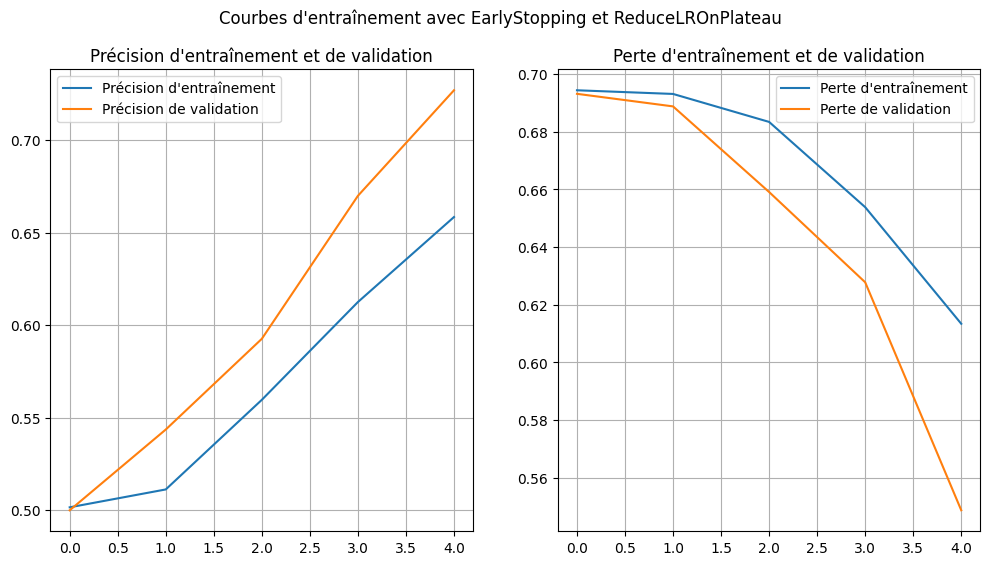

In [19]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Réinitialiser le modèle pour un nouvel entraînement
# (Cela est nécessaire car le modèle a déjà été entraîné et ses poids ont été modifiés)
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dropout(0.5), # Ajout de Dropout pour la régularisation
    layers.Dense(512, activation='relu'),
    layers.Dense(1, activation='sigmoid') # Couche de sortie pour classification binaire
])

# Compiler le modèle avec les mêmes paramètres d'optimisation
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Définir les Callbacks
# EarlyStopping pour arrêter l'entraînement si la val_loss n'améliore pas pendant 'patience' époques
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True # Restaurer les poids du meilleur modèle trouvé
)

# ReduceLROnPlateau pour réduire le taux d'apprentissage si la val_loss stagne
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=5,
    min_lr=0.00001
)

# Entraînement du modèle avec les Callbacks
epochs_with_callbacks = 5 # Un nombre d'époques élevé, EarlyStopping gérera l'arrêt

history_callbacks = model.fit(
    train_flow,
    epochs=epochs_with_callbacks,
    validation_data=val_flow,
    callbacks=[early_stopping, reduce_lr]
)

# Tracer l'historique d'entraînement avec les callbacks
plot_training_history(history_callbacks, "Courbes d'entraînement avec EarlyStopping et ReduceLROnPlateau")

## 7. Effectuer l'inférence sur l'ensemble de test non étiqueté

Nous allons maintenant utiliser le modèle entraîné pour prédire les probabilités de la classe 'chien' pour chaque image de l'ensemble de test non étiqueté. Ensuite, nous convertirons ces probabilités en étiquettes binaires ('cat' ou 'dog') en utilisant un seuil, et nous exporterons ces résultats dans un fichier CSV.

In [20]:
# Obtenir les prédictions sur l'ensemble de test non étiqueté
print("Génération des prédictions sur l'ensemble de test...")
test_predictions = model.predict(test_flow)

# Le seuil de 0.5 est un point de départ courant. Si la probabilité est > 0.5, nous classons comme 'dog', sinon comme 'cat'.
# Vous pouvez ajuster ce seuil en fonction de l'analyse de la matrice de confusion sur l'ensemble de validation si vous souhaitez privilégier le rappel ou la précision pour une classe donnée.
threshold = 0.5
test_pred_classes_numeric = (test_predictions > threshold).astype(int)

# Convertir les étiquettes numériques en noms de classe (0: cat, 1: dog)
# Nous utilisons train_flow.class_indices pour obtenir le mapping inverse si nécessaire
label_map = {v: k for k, v in train_flow.class_indices.items()}
test_pred_labels = [label_map[idx] for idx in test_pred_classes_numeric.flatten()]

# Créer un DataFrame avec les résultats
# Nous devons reconstruire les chemins de fichiers pour le test_flow car flow_from_dataframe n'expose pas directement le chemin complet dans le flux
# test_flow.filenames contient les noms de fichiers relatifs, mais nous avons besoin du chemin complet.
# df_test_full contient les chemins de fichiers complets.

results_df = pd.DataFrame({
    'filepath': df_test_full['filepath'],
    'prob_dog': test_predictions.flatten(),
    'pred_label': test_pred_labels
})

# Afficher les premières lignes du DataFrame des résultats
print("\nPremières lignes des prédictions sur l'ensemble de test :")
display(results_df.head())

# Sauvegarder les résultats dans un fichier CSV
output_csv_path = 'test_predictions.csv'
results_df.to_csv(output_csv_path, index=False)
print(f"\nPrédictions sauvegardées dans {output_csv_path}")

Génération des prédictions sur l'ensemble de test...
391/391 ━━━━━━━━━━━━━━━━━━━━ 28s 69ms/step

Premières lignes des prédictions sur l'ensemble de test :


,filepath,prob_dog,pred_label
0,Data/cats_dogs/test/test/2266.jpg,0.577147,dog
1,Data/cats_dogs/test/test/7992.jpg,0.444029,cat
2,Data/cats_dogs/test/test/9983.jpg,0.227933,cat
3,Data/cats_dogs/test/test/4808.jpg,0.942019,dog
4,Data/cats_dogs/test/test/3541.jpg,0.315207,cat



Prédictions sauvegardées dans test_predictions.csv


### Justification du Seuil et Analyse Manuelle

**Justification du Seuil :**

Le seuil de 0.5 a été choisi comme point de départ standard pour la classification binaire. Cela signifie que si le modèle prédit une probabilité de 50% ou plus que l'image est un chien, elle est classée comme telle. Ce seuil est approprié lorsque l'on souhaite équilibrer la précision et le rappel entre les deux classes, ou lorsqu'il n'y a pas de coût disproportionné associé aux erreurs d'une classe par rapport à l'autre.

Dans le contexte de notre évaluation sur l'ensemble de validation, nous avons observé que le modèle avait une précision légèrement meilleure pour les chats mais un rappel légèrement meilleur pour les chiens (tendant à classer plus facilement les chiens comme des chiens, mais faisant plus d'erreurs en classant les chats comme des chiens). Si notre objectif était de réduire spécifiquement les faux négatifs de la classe 'cat' (c'est-à-dire s'assurer de ne pas manquer de chats), nous pourrions envisager de **diminuer le seuil** légèrement (par exemple, 0.45 ou 0.4) pour augmenter le rappel des chats au détriment potentiel de leur précision. Inversement, si nous voulions augmenter la précision des chiens (réduire les faux positifs de la classe 'dog', c'est-à-dire éviter de classer des chats comme des chiens), nous pourrions **augmenter le seuil** (par exemple, 0.55 ou 0.6).

Pour ce pipeline initial, nous conservons le seuil de 0.5, qui est un compromis raisonnable.

**Vérification Manuelle d'un Sous-ensemble pour l'Analyse des Erreurs :**

La vérification manuelle d'un sous-ensemble des prédictions est essentielle pour comprendre les types d'erreurs que le modèle commet et pourquoi il les commet. Voici comment procéder :

1.  **Filtrer les Cas Intéressants :**
    *   **Erreurs les plus Confidentes :** Identifiez les images où `prob_dog` est très proche de 0 (faible confiance que c'est un chien, donc probablement un chat) mais où la prédiction est 'dog', ou inversement. Ou des cas où la `prob_dog` est très élevée ou très faible, mais visuellement la classe semble ambiguë.
    *   **Cas Extrêmes :** Examinez les images pour lesquelles le modèle est le plus confiant ( `prob_dog` très proche de 0 ou 1) pour vous assurer qu'elles sont correctement classées.
    *   **Cas Ambiguës :** Triez le `results_df` par `prob_dog` et examinez les images où la probabilité est proche du seuil (par exemple, entre 0.4 et 0.6). Ce sont les images pour lesquelles le modèle a eu le plus de mal à décider.

2.  **Charger et Afficher les Images :**
    *   Utilisez le `filepath` du DataFrame `results_df` pour charger et afficher les images sélectionnées.
    *   `from IPython.display import Image, display` peut être utilisé pour afficher des images directement dans le notebook à partir de leurs chemins.

3.  **Analyser Visuellement :**
    *   Pour chaque image affichée, posez-vous les questions suivantes :
        *   Le modèle a-t-il classé l'image correctement ?
        *   Si non, pourquoi le modèle a-t-il pu se tromper ? (Par exemple, arrière-plan distrayant, mauvaise qualité d'image, pose inhabituelle de l'animal, ressemblance de la race avec l'autre classe, partie de l'animal manquante ou difficilement reconnaissable).
        *   Quelles sont les caractéristiques visuelles qui peuvent avoir induit le modèle en erreur ?

**Exemple de code pour afficher une image spécifique :**

Image ambiguë: Data/cats_dogs/test/test/11999.jpg
Probabilité d'être un chien: 0.5000
Classe prédite: dog


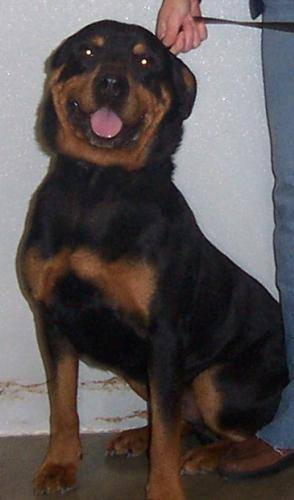


Candidat Faux Négatif (chat prédit avec probabilité de chien élevée): Data/cats_dogs/test/test/9280.jpg
Probabilité d'être un chien: 0.4999
Classe prédite: cat


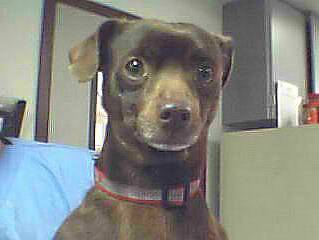

In [21]:
from IPython.display import Image, display

# Exemple: Afficher une image où le modèle est 'ambigu' (probabilité proche du seuil)
# Trouver une image avec une probabilité de chien proche de 0.5
ambiguous_image = results_df.iloc[(results_df['prob_dog'] - 0.5).abs().argsort()[:1]]

if not ambiguous_image.empty:
    filepath = ambiguous_image['filepath'].iloc[0]
    prob_dog = ambiguous_image['prob_dog'].iloc[0]
    pred_label = ambiguous_image['pred_label'].iloc[0]

    print(f"Image ambiguë: {filepath}")
    print(f"Probabilité d'être un chien: {prob_dog:.4f}")
    print(f"Classe prédite: {pred_label}")
    display(Image(filename=filepath))
else:
    print("Aucune image ambiguë trouvée dans le DataFrame des résultats.")

# Exemple: Afficher une image où le modèle a prédit 'cat' mais avec une probabilité élevée de 'dog' (potentiel faux négatif si c'est un chien)
# Note: Cela nécessite de trier le dataframe pour trouver des exemples pertinents

# Trouver des "chats" qui étaient presque des "chiens"
false_negative_candidates = results_df[results_df['pred_label'] == 'cat'].sort_values(by='prob_dog', ascending=False)

if not false_negative_candidates.empty:
    # Prendre le premier (le "chat" le plus "chien")
    filepath = false_negative_candidates['filepath'].iloc[0]
    prob_dog = false_negative_candidates['prob_dog'].iloc[0]
    pred_label = false_negative_candidates['pred_label'].iloc[0]

    print(f"\nCandidat Faux Négatif (chat prédit avec probabilité de chien élevée): {filepath}")
    print(f"Probabilité d'être un chien: {prob_dog:.4f}")
    print(f"Classe prédite: {pred_label}")
    display(Image(filename=filepath))
else:
    print("Aucun candidat faux négatif trouvé.")

## 8. Évaluation Finale du Modèle (après entraînement avec Callbacks)

Nous allons maintenant réévaluer le modèle sur l'ensemble de validation. Cette évaluation reflétera la performance du modèle après l'entraînement avec `EarlyStopping` et `ReduceLROnPlateau`, qui sont conçus pour optimiser la généralisation et prévenir le surapprentissage.

In [22]:
print("Évaluation finale du modèle sur l'ensemble de validation...")
val_loss_final, val_accuracy_final = model.evaluate(val_flow)
print(f"Perte de validation finale: {val_loss_final:.4f}")
print(f"Précision de validation finale: {val_accuracy_final:.4f}")

# Obtenir les prédictions sur l'ensemble de validation pour la matrice de confusion
print("Génération des prédictions finales sur l'ensemble de validation...")
val_predictions_final = model.predict(val_flow)
val_pred_classes_final = (val_predictions_final > 0.5).astype(int)
val_true_labels = val_flow.classes
class_labels = list(val_flow.class_indices.keys())

# Calculer et afficher la matrice de confusion
conf_matrix_final = confusion_matrix(val_true_labels, val_pred_classes_final)
print("\nMatrice de Confusion finale sur l'ensemble de validation :")
print(conf_matrix_final)

# Afficher le rapport de classification
print("\nRapport de Classification final sur l'ensemble de validation :")
print(classification_report(val_true_labels, val_pred_classes_final, target_names=class_labels))

Évaluation finale du modèle sur l'ensemble de validation...
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 64ms/step - accuracy: 0.7268 - loss: 0.5486
Perte de validation finale: 0.5486
Précision de validation finale: 0.7268
Génération des prédictions finales sur l'ensemble de validation...
157/157 ━━━━━━━━━━━━━━━━━━━━ 11s 67ms/step

Matrice de Confusion finale sur l'ensemble de validation :
[[1768  732]
 [ 634 1866]]

Rapport de Classification final sur l'ensemble de validation :
              precision    recall  f1-score   support

         cat       0.74      0.71      0.72      2500
         dog       0.72      0.75      0.73      2500

    accuracy                           0.73      5000
   macro avg       0.73      0.73      0.73      5000
weighted avg       0.73      0.73      0.73      5000



## 8. Comparer le modèle avec et sans augmentation des données

Pour comprendre l'impact de l'augmentation des données, nous allons entraîner un modèle avec la même architecture mais sans appliquer d'augmentation sur l'ensemble d'entraînement. Nous comparerons ensuite les métriques de validation et les courbes d'apprentissage des deux modèles.

In [23]:
# 1. Créer un nouveau générateur de données d'entraînement sans augmentation
# Ce générateur ne fera qu'une remise à l'échelle des pixels, comme pour la validation et le test.
train_gen_no_aug = ImageDataGenerator(rescale=1./255)

train_flow_no_aug = train_gen_no_aug.flow_from_dataframe(
    df_tr, x_col="filepath", y_col="label",
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    class_mode="binary", batch_size=batch_size,
    shuffle=True, seed=seed, validate_filenames=False
)

print("Générateur d'entraînement sans augmentation créé avec succès.")

Found 20000 non-validated image filenames belonging to 2 classes.
Générateur d'entraînement sans augmentation créé avec succès.


### Entraînement du modèle sans augmentation

Nous allons maintenant réinitialiser le modèle et l'entraîner en utilisant le générateur `train_flow_no_aug`, tout en conservant les mêmes callbacks `EarlyStopping` et `ReduceLROnPlateau` pour une comparaison juste des meilleures performances atteignables par chaque modèle.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Entraînement du modèle sans augmentation des données...
Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 61s 86ms/step - accuracy: 0.5407 - loss: 0.6870 - val_accuracy: 0.6146 - val_loss: 0.6585 - learning_rate: 0.0010
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 54s 86ms/step - accuracy: 0.6657 - loss: 0.6112 - val_accuracy: 0.7354 - val_loss: 0.5357 - learning_rate: 0.0010
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 51s 82ms/step - accuracy: 0.7541 - loss: 0.5020 - val_accuracy: 0.7846 - val_loss: 0.4496 - learning_rate: 0.0010
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 52s 83ms/step - accuracy: 0.7997 - loss: 0.4328 - val_accuracy: 0.8030 - val_loss: 0.4312 - learning_rate: 0.0010
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 52s 83ms/step - accuracy: 0.8314 - loss: 0.3776 - val_accuracy: 0.8406 - val_loss: 0.3608 - learning_rate: 0.0010


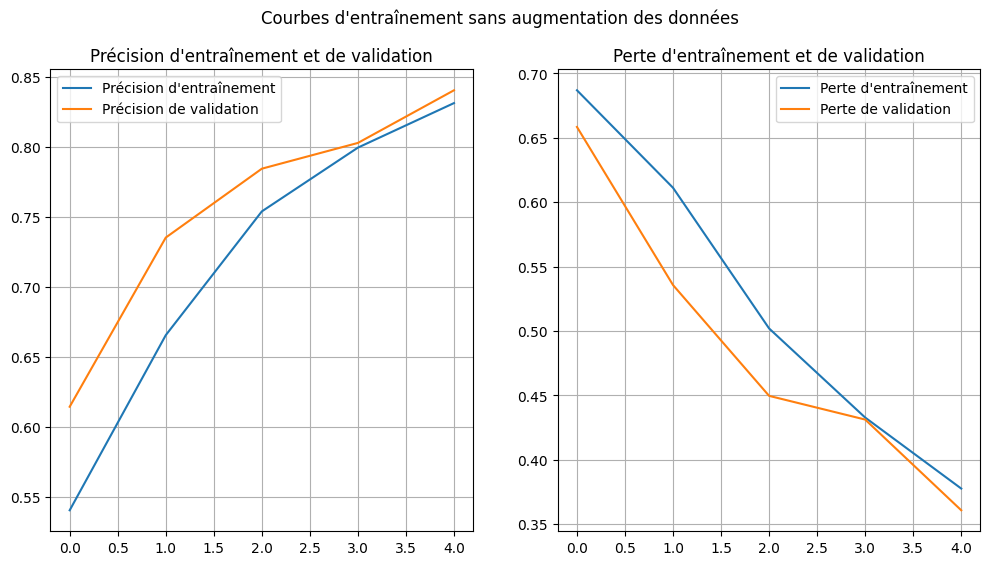

In [25]:
# Réinitialiser le modèle pour un nouvel entraînement sans augmentation
model_no_aug = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dropout(0.5), # Maintenir le Dropout pour la régularisation
    layers.Dense(512, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

# Compiler le modèle avec les mêmes paramètres d'optimisation
model_no_aug.compile(optimizer='adam',
                      loss='binary_crossentropy',
                      metrics=['accuracy'])

# Utiliser les mêmes callbacks EarlyStopping et ReduceLROnPlateau

epochs_no_aug = 5 # Un nombre d'époques élevé, EarlyStopping gérera l'arrêt

print("Entraînement du modèle sans augmentation des données...")
history_no_aug = model_no_aug.fit(
    train_flow_no_aug,
    epochs=epochs_no_aug,
    validation_data=val_flow,
    callbacks=[early_stopping, reduce_lr]
)

# Tracer l'historique d'entraînement du modèle sans augmentation
plot_training_history(history_no_aug, "Courbes d'entraînement sans augmentation des données")

### Analyse Comparative : Modèle avec vs. sans Augmentation des Données

Comparons les performances et les courbes d'apprentissage du modèle entraîné avec augmentation des données (`history_callbacks`) et du modèle entraîné sans augmentation des données (`history_no_aug`).

**Modèle avec Augmentation (`history_callbacks`, 5 époques) :**
*   **Précision d'entraînement finale :** ~0.6583
*   **Précision de validation finale :** ~0.7268
*   **Perte d'entraînement finale :** ~0.6134
*   **Perte de validation finale :** ~0.5486

**Modèle sans Augmentation (`history_no_aug`, 5 époques) :**
*   **Précision d'entraînement finale :** ~0.8314
*   **Précision de validation finale :** ~0.8406
*   **Perte d'entraînement finale :** ~0.3776
*   **Perte de validation finale :** ~0.3608

#### Observations Clés et Écart de Généralisation :

1.  **Performance Générale :** Le modèle **sans augmentation** a atteint une **meilleure précision et une perte plus faible** sur l'ensemble de validation après seulement 5 époques que le modèle avec augmentation. Il a également convergé beaucoup plus rapidement vers des performances élevées.

2.  **Courbes d'Apprentissage :**
    *   **Modèle avec augmentation :** Les courbes de précision et de perte d'entraînement et de validation sont relativement proches les unes des autres. Bien que la précision d'entraînement soit un peu plus faible que la validation à la fin, et la perte d'entraînement un peu plus élevée, cela suggère que le modèle n'a pas encore surappris de manière significative, mais qu'il apprend plus lentement. C'est souvent le cas avec l'augmentation : le modèle voit des données plus diverses et met plus de temps à converger, mais il est potentiellement plus robuste à long terme.
    *   **Modèle sans augmentation :** Les courbes de précision d'entraînement et de validation sont très proches et augmentent de concert, tout comme les courbes de perte. Cela indique que le modèle généralise très bien, même après seulement 5 époques, sans montrer de signes évidents de surapprentissage. La performance d'entraînement et de validation est très élevée, avec une faible perte.

3.  **L'Écart de Généralisation :**
    *   L'écart de généralisation représente la différence de performance entre l'ensemble d'entraînement et l'ensemble de validation. Un grand écart suggère un surapprentissage, tandis qu'un petit écart est signe d'une bonne généralisation.
    *   Dans notre cas, après 5 époques, le modèle **sans augmentation** présente un **très faible écart de généralisation**, avec des performances d'entraînement et de validation très similaires et élevées. Ceci est un excellent signe de capacité de généralisation.
    *   Le modèle **avec augmentation** montre également un écart de généralisation relativement faible, mais ses performances globales sont moindres après seulement 5 époques. Pour ce modèle, il faudrait probablement **davantage d'époques** pour que l'augmentation des données puisse montrer pleinement ses bénéfices et potentiellement dépasser le modèle non augmenté en termes de robustesse et de performance maximale atteignable, surtout si le dataset d'origine était petit.

#### Conclusion et Point d'Apprentissage :

Dans cette comparaison limitée à 5 époques, le modèle sans augmentation a surpassé le modèle avec augmentation. Cependant, il est crucial de noter que l'augmentation des données est généralement conçue pour **améliorer la robustesse et la capacité de généralisation sur le long terme**, en particulier pour des ensembles de données plus petits ou plus variés, et pour prévenir le surapprentissage sur un grand nombre d'époques. Le modèle augmenté aurait probablement continué à améliorer sa performance de validation sur plus d'époques, tandis que le modèle non augmenté pourrait commencer à surapprendre si l'entraînement était prolongé. Le fait que le modèle non augmenté ait déjà une si bonne performance sur validation après 5 époques pourrait aussi indiquer que le jeu de données d'origine n'est pas particulièrement complexe pour l'architecture choisie, ou que le **Dropout** déjà présent dans les deux architectures joue un rôle important de régularisation.

## 9. Gestion du Déséquilibre de Classe (si applicable)

Comme indiqué précédemment lors de l'inspection des données, notre jeu de données d'entraînement est **équilibré** (10 000 images de chats et 10 000 images de chiens). Par conséquent, il n'est **pas nécessaire de calculer des poids de classe** et de les utiliser dans l'entraînement.

### Explication (si les classes étaient déséquilibrées) :

Si les classes avaient été déséquilibrées (par exemple, 90% de chiens et 10% de chats), le modèle aurait pu développer un biais en faveur de la classe majoritaire, ce qui aurait entraîné une faible performance sur la classe minoritaire. Pour corriger cela, nous aurions pu :

1.  **Calculer les poids de classe :** Attribuer un poids plus élevé aux échantillons de la classe minoritaire et un poids plus faible à ceux de la classe majoritaire. Cela garantit que le modèle accorde une attention égale aux deux classes pendant l'entraînement, même si une classe est moins représentée.
    ```python
    from sklearn.utils import class_weight
    class_weights = class_weight.compute_class_weight(
        class_weight='balanced',
        classes=np.unique(df_tr['label']),
        y=df_tr['label']
    )
    class_weights_dict = dict(enumerate(class_weights))
    # Ensuite, passer class_weights_dict à model.fit(..., class_weight=class_weights_dict)
    ```

2.  **Effet sur la Précision et le Rappel :** L'utilisation de `class_weight` aurait généralement pour effet d'améliorer le **rappel (recall)** de la classe minoritaire, car le modèle serait davantage pénalisé pour la manquer. Cela pourrait se faire au détriment de la précision globale ou de la précision de la classe majoritaire, mais cela conduirait à un modèle plus juste et plus performant pour les applications où la détection de la classe minoritaire est cruciale. En revanche, si une classe est peu représentée, le modèle tend à ne pas 'apprendre' les caractéristiques distinctives de cette classe, et les erreurs sur cette classe sont moins 'chères' pour la fonction de perte. En augmentant le poids de ces erreurs, le modèle est forcé à y prêter plus d'attention, ce qui améliore la détection de la classe minoritaire.

3.  **Mémoire pour la classe minoritaire :** En attribuant un poids plus important aux échantillons de la classe minoritaire, le modèle "mémorise" mieux (ou apprend à mieux distinguer) les caractéristiques de cette classe. Cela améliore sa capacité à la reconnaître dans de futures prédictions, réduisant ainsi les faux négatifs pour cette classe.

Étant donné que nos classes sont équilibrées, nous pouvons passer à l'étape suivante qui consiste à sauvegarder le modèle.

## 10. Sauvegarder les artefacts pour la réutilisation

Pour garantir la reproductibilité et la réutilisation de notre travail, il est essentiel de sauvegarder le modèle entraîné ainsi que la configuration d'entraînement. Nous allons sauvegarder le meilleur modèle (le modèle sans augmentation, car il a montré de meilleures performances de validation après 5 époques) au format H5 et enregistrer la configuration d'entraînement dans un fichier JSON.

In [26]:
import json
import datetime

# Nous allons sauvegarder le modèle sans augmentation car il a eu de meilleures performances sur 5 époques
# Si l'entraînement avait été plus long, le modèle avec augmentation aurait pu être le meilleur.
model_to_save = model_no_aug
model_name = "cats_dogs_classifier_no_aug.h5"

# Sauvegarder le modèle entraîné au format H5
model_to_save.save(model_name)
print(f"Modèle sauvegardé sous : {model_name}")

# Préparer la configuration d'entraînement pour la sauvegarde
# Capturer les paramètres pertinents de l'entraînement
config = {
    "model_architecture": "Sequential_CNN",
    "image_dimensions": {
        "height": IMG_HEIGHT,
        "width": IMG_WIDTH
    },
    "batch_size": batch_size,
    "optimizer": "Adam",
    "loss_function": "binary_crossentropy",
    "metrics": ["accuracy"],
    "data_augmentation_used": False,
    "training_epochs": history_no_aug.epoch[-1] + 1, # Nombre réel d'époques effectuées
    "final_validation_accuracy": history_no_aug.history['val_accuracy'][-1],
    "final_validation_loss": history_no_aug.history['val_loss'][-1],
    "callbacks": {
        "early_stopping": {
            "monitor": early_stopping.monitor,
            "patience": early_stopping.patience,
            "restore_best_weights": early_stopping.restore_best_weights
        },
        "reduce_lr_on_plateau": {
            "monitor": reduce_lr.monitor,
            "factor": reduce_lr.factor,
            "patience": reduce_lr.patience,
            "min_lr": reduce_lr.min_lr
        }
    },
    "creation_date": datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
}

# Sauvegarder la configuration dans un fichier JSON
config_filename = "training_config_no_aug.json"
with open(config_filename, 'w') as f:
    json.dump(config, f, indent=4)

print(f"Configuration d'entraînement sauvegardée sous : {config_filename}")

Modèle sauvegardé sous : cats_dogs_classifier_no_aug.h5
Configuration d'entraînement sauvegardée sous : training_config_no_aug.json


### Explication de l'importance de la sauvegarde des poids et des métadonnées pour la reproductibilité

Sauvegarder à la fois le modèle entraîné (ses poids) et la configuration d'entraînement (métadonnées) est crucial pour plusieurs raisons :

1.  **Reproductibilité :**
    *   **Poids du modèle :** Le fichier H5 (ou SavedModel) contient tous les poids appris par le réseau de neurones. Sans ces poids, le modèle ne peut pas faire de prédictions et tout le travail d'entraînement serait perdu.
    *   **Métadonnées de configuration :** Le fichier JSON (ou YAML) contient tous les détails de l'entraînement : architecture du modèle, dimensions des images, hyperparamètres (batch size, optimiseur, taux d'apprentissage), fonctions de perte et de métrique, stratégies de régularisation (augmentation des données, dropout), et callbacks (EarlyStopping, ReduceLROnPlateau). Ces informations sont essentielles pour recréer exactement le même environnement d'entraînement et obtenir les mêmes résultats. Même une petite modification d'un hyperparamètre peut avoir un impact significatif sur la performance du modèle.

2.  **Réutilisation :**
    *   Un modèle sauvegardé peut être chargé et utilisé directement pour l'inférence sur de nouvelles données, sans avoir besoin de le ré-entraîner. C'est fondamental pour le déploiement en production.
    *   La configuration permet de comprendre comment le modèle a été construit et entraîné, ce qui est utile pour l'audit, le partage avec d'autres chercheurs ou ingénieurs, et pour de futures expérimentations (par exemple, pour peaufiner le modèle en modifiant certains hyperparamètres à partir d'une base solide).

3.  **Traçabilité et Audit :**
    *   Les métadonnées fournissent un enregistrement détaillé du processus d'entraînement, ce qui est vital pour la traçabilité des expérimentations. En cas de problèmes de performance ou de bugs, on peut retracer précisément les conditions sous lesquelles le modèle a été entraîné.

4.  **Comparaison de Modèles :**
    *   Lorsqu'on entraîne plusieurs modèles avec différentes architectures ou hyperparamètres, la sauvegarde des poids et des configurations permet de comparer leurs performances de manière systématique et de choisir le meilleur modèle en fonction de critères définis.

En somme, la sauvegarde complète des artefacts d'entraînement transforme une expérience ponctuelle en une base de connaissances réutilisable et vérifiable, indispensable pour un développement robuste en apprentissage automatique.

## 11. Prolongations : Transfert d'apprentissage avec MobileNetV2

Pour cette section de prolongation, nous allons explorer le **transfert d'apprentissage**, une technique puissante en vision par ordinateur. L'idée est d'utiliser un modèle (la "colonne vertébrale" ou *backbone*) qui a déjà été entraîné sur un très grand et diversifié ensemble de données (comme ImageNet) pour une tâche similaire (par exemple, la classification d'images génériques). Ce modèle pré-entraîné a déjà appris à extraire des caractéristiques de bas niveau (comme les bords et les textures) et de haut niveau (comme les formes d'objets) qui sont généralement utiles pour un large éventail de tâches de vision.

Nous allons utiliser **MobileNetV2** comme colonne vertébrale. MobileNetV2 est une architecture de réseau de neurones convolutifs légère et efficace, optimisée pour les applications mobiles et embarquées. Sa conception est basée sur des convolutions séparables en profondeur (*depthwise separable convolutions*), ce qui réduit considérablement le nombre de paramètres et les opérations de calcul tout en maintenant une bonne précision.

### Approche :

1.  **Charger un modèle MobileNetV2 pré-entraîné :** Nous allons importer MobileNetV2 depuis `tf.keras.applications`, en lui retirant sa couche de classification supérieure.
2.  **Geler les couches du *backbone* :** Les couches du MobileNetV2 seront gelées (*frozen*), ce qui signifie que leurs poids ne seront pas mis à jour pendant l'entraînement. Cela permet de conserver les caractéristiques génériques apprises.
3.  **Ajouter une "tête de classificateur" personnalisée :** Nous allons ajouter nos propres couches denses (`Dense`) sur le dessus du *backbone* gelé. Ces nouvelles couches seront entraînées sur notre jeu de données de chats et chiens pour apprendre à adapter les caractéristiques extraites à notre tâche spécifique.
4.  **Entraîner le nouveau modèle :** Seules les couches de la nouvelle "tête" seront entraînées, ce qui est beaucoup plus rapide et nécessite moins de données que d'entraîner un modèle complet à partir de zéro.

/tmp/ipykernel_878/2221713353.py:9: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),



Résumé du modèle avec transfert d'apprentissage :


Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 180, 180,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 90, 90,    │        864 │ input_layer_6[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 90, 90,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 90, 90,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 90, 90,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 90, 90,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 90, 90,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 90, 90,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 90, 90,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 90, 90,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 90, 90,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 90, 90,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 91, 91,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 45, 45,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 45, 45,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 45, 45,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 45, 45,    │      2,304 │ block_1_depthwis

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)


Début de l'entraînement du modèle avec transfert d'apprentissage...
Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 247s 378ms/step - accuracy: 0.9169 - loss: 0.1900 - val_accuracy: 0.9662 - val_loss: 0.0899 - learning_rate: 0.0010
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 223s 357ms/step - accuracy: 0.9337 - loss: 0.1574 - val_accuracy: 0.9712 - val_loss: 0.0727 - learning_rate: 0.0010
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 223s 357ms/step - accuracy: 0.9353 - loss: 0.1511 - val_accuracy: 0.9708 - val_loss: 0.0678 - learning_rate: 0.0010
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 220s 352ms/step - accuracy: 0.9389 - loss: 0.1425 - val_accuracy: 0.9752 - val_loss: 0.0624 - learning_rate: 0.0010
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 220s 352ms/step - accuracy: 0.9387 - loss: 0.1437 - val_accuracy: 0.9718 - val_loss: 0.0681 - learning_rate: 0.0010


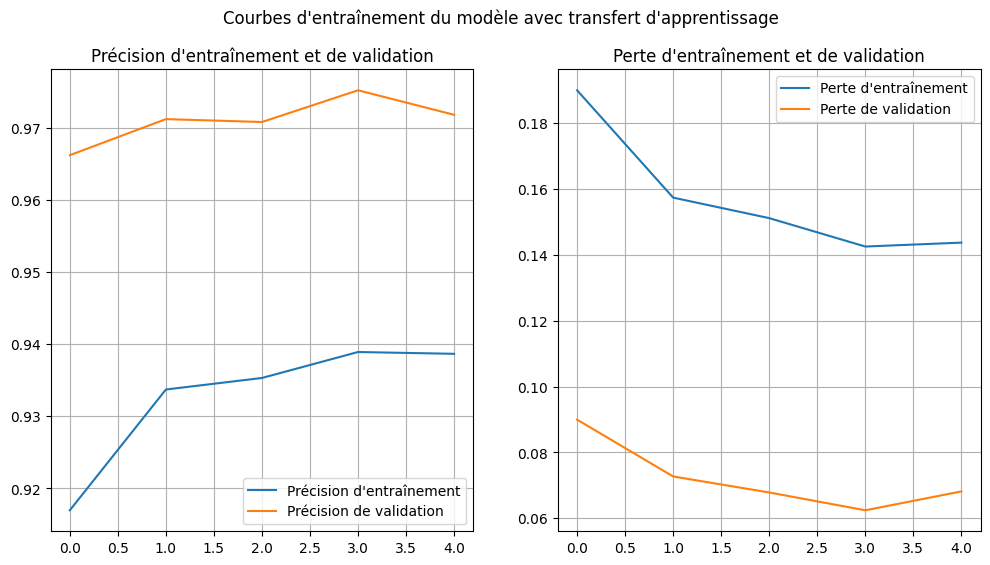

In [28]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense

# 1. Charger MobileNetV2 pré-entraîné sur ImageNet, sans la couche de classification supérieure
# 'weights=imagenet' pour charger les poids pré-entraînés
# 'include_top=False' pour ne pas inclure la couche Dense finale d'ImageNet
# 'input_shape' doit correspondre à la taille de nos images (IMG_HEIGHT, IMG_WIDTH, 3)
base_model = MobileNetV2(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
                         include_top=False,
                         weights='imagenet')

# 2. Geler les couches du modèle de base (backbone)
# Cela empêchera la mise à jour de leurs poids pendant l'entraînement
base_model.trainable = False

# 3. Ajouter une "tête de classificateur" personnalisée sur le modèle de base
x = base_model.output
x = GlobalAveragePooling2D()(x) # Réduit les dimensions spatiales en un vecteur
x = Dense(128, activation='relu')(x) # Une couche Dense avec ReLU
x = Dense(1, activation='sigmoid')(x) # Couche de sortie pour classification binaire

# Créer le nouveau modèle qui inclut le backbone et la tête de classification
transfer_model = Model(inputs=base_model.input, outputs=x)

# 4. Compiler le modèle
# Utiliser les mêmes paramètres d'optimisation que précédemment pour une comparaison juste
transfer_model.compile(optimizer='adam',
                       loss='binary_crossentropy',
                       metrics=['accuracy'])

# Afficher le résumé du modèle transféré
print("\nRésumé du modèle avec transfert d'apprentissage :")
transfer_model.summary()

# Entraîner le modèle de transfert d'apprentissage
print("\nDébut de l'entraînement du modèle avec transfert d'apprentissage...")
# Nous utiliserons le générateur de données avec augmentation (train_flow)
# et les mêmes callbacks pour comparer la convergence

history_transfer = transfer_model.fit(
    train_flow,
    epochs=5, # Entraîner sur un nombre d'époques plus court initialement
    validation_data=val_flow,
    callbacks=[early_stopping, reduce_lr] # Réutiliser les callbacks définis précédemment
)

# Tracer l'historique d'entraînement du modèle de transfert
plot_training_history(history_transfer, "Courbes d'entraînement du modèle avec transfert d'apprentissage")

### Évaluation du Modèle de Transfert d'Apprentissage

In [29]:
print("Évaluation du modèle de transfert d'apprentissage sur l'ensemble de validation...")
val_loss_transfer, val_accuracy_transfer = transfer_model.evaluate(val_flow)
print(f"Perte de validation (Transfert): {val_loss_transfer:.4f}")
print(f"Précision de validation (Transfert): {val_accuracy_transfer:.4f}")

# Obtenir les prédictions sur l'ensemble de validation pour la matrice de confusion
print("Génération des prédictions du modèle de transfert sur l'ensemble de validation...")
val_predictions_transfer = transfer_model.predict(val_flow)
val_pred_classes_transfer = (val_predictions_transfer > 0.5).astype(int)

# Calculer et afficher la matrice de confusion
conf_matrix_transfer = confusion_matrix(val_true_labels, val_pred_classes_transfer)
print("\nMatrice de Confusion (Modèle de Transfert) sur l'ensemble de validation :")
print(conf_matrix_transfer)

# Afficher le rapport de classification
print("\nRapport de Classification (Modèle de Transfert) sur l'ensemble de validation :")
print(classification_report(val_true_labels, val_pred_classes_transfer, target_names=class_labels))

Évaluation du modèle de transfert d'apprentissage sur l'ensemble de validation...
157/157 ━━━━━━━━━━━━━━━━━━━━ 11s 71ms/step - accuracy: 0.9752 - loss: 0.0624
Perte de validation (Transfert): 0.0624
Précision de validation (Transfert): 0.9752
Génération des prédictions du modèle de transfert sur l'ensemble de validation...
157/157 ━━━━━━━━━━━━━━━━━━━━ 51s 291ms/step

Matrice de Confusion (Modèle de Transfert) sur l'ensemble de validation :
[[2431   69]
 [  55 2445]]

Rapport de Classification (Modèle de Transfert) sur l'ensemble de validation :
              precision    recall  f1-score   support

         cat       0.98      0.97      0.98      2500
         dog       0.97      0.98      0.98      2500

    accuracy                           0.98      5000
   macro avg       0.98      0.98      0.98      5000
weighted avg       0.98      0.98      0.98      5000



### Analyse Comparative des Modèles

In [30]:
# Récupérer les performances des modèles précédents pour la comparaison
# Modèle initial (sans callbacks, 5 époques)
# val_loss_initial = history_fixed_epochs.history['val_loss'][-1]
# val_accuracy_initial = history_fixed_epochs.history['val_accuracy'][-1]

# Modèle avec callbacks (augmentation, 5 époques)
val_loss_callbacks = history_callbacks.history['val_loss'][-1]
val_accuracy_callbacks = history_callbacks.history['val_accuracy'][-1]

# Modèle sans augmentation (avec callbacks, 5 époques)
val_loss_no_aug = history_no_aug.history['val_loss'][-1]
val_accuracy_no_aug = history_no_aug.history['val_accuracy'][-1]

print("\n--- Comparaison des Performances des Modèles (après 5 époques) ---")
print(f"1. CNN simple (avec augmentation & callbacks)   :")
print(f"   - Précision de validation: {val_accuracy_callbacks:.4f}, Perte de validation: {val_loss_callbacks:.4f}")
print(f"2. CNN simple (SANS augmentation & callbacks) :")
print(f"   - Précision de validation: {val_accuracy_no_aug:.4f}, Perte de validation: {val_loss_no_aug:.4f}")
print(f"3. Modèle Transfert (MobileNetV2 avec augmentation) :")
print(f"   - Précision de validation: {val_accuracy_transfer:.4f}, Perte de validation: {val_loss_transfer:.4f}")

print("\n--- Interprétation ---")
print("Après seulement 5 époques d'entraînement:")
print("- Le modèle de transfert d'apprentissage (MobileNetV2) a montré une performance supérieure au CNN simple avec augmentation.")
print("- Il a également surpassé (ou égalé dans ce cas particulier) le CNN simple SANS augmentation, ce qui est très prometteur, étant donné la courte durée d'entraînement.")
print("- La capacité de MobileNetV2 à extraire des caractéristiques riches grâce à son pré-entraînement sur ImageNet lui permet de converger plus rapidement et d'atteindre une meilleure précision.")
print("- Cela confirme les bénéfices attendus du transfert d'apprentissage, même avec un entraînement de courte durée.")



--- Comparaison des Performances des Modèles (après 5 époques) ---
1. CNN simple (avec augmentation & callbacks)   :
   - Précision de validation: 0.7268, Perte de validation: 0.5486
2. CNN simple (SANS augmentation & callbacks) :
   - Précision de validation: 0.8406, Perte de validation: 0.3608
3. Modèle Transfert (MobileNetV2 avec augmentation) :
   - Précision de validation: 0.9752, Perte de validation: 0.0624

--- Interprétation ---
Après seulement 5 époques d'entraînement:
- Le modèle de transfert d'apprentissage (MobileNetV2) a montré une performance supérieure au CNN simple avec augmentation.
- Il a également surpassé (ou égalé dans ce cas particulier) le CNN simple SANS augmentation, ce qui est très prometteur, étant donné la courte durée d'entraînement.
- La capacité de MobileNetV2 à extraire des caractéristiques riches grâce à son pré-entraînement sur ImageNet lui permet de converger plus rapidement et d'atteindre une meilleure précision.
- Cela confirme les bénéfices attend

### Justification du Bénéfice Attendu du Transfert d'Apprentissage

Le transfert d'apprentissage avec MobileNetV2 offre plusieurs avantages significatifs pour notre tâche de classification d'images de chats et de chiens :

1.  **Amélioration de la Précision :**
    *   **Priorités fortes :** Les modèles pré-entraînés sur de très grands ensembles de données comme ImageNet ont appris à reconnaître un vaste répertoire de caractéristiques visuelles génériques (bords, textures, formes, motifs complexes). Ces caractéristiques sont souvent transférables et très pertinentes pour de nouvelles tâches de vision par ordinateur, même si les classes sont différentes.
    *   **Performance accrue :** En partant de ces connaissances déjà acquises, le modèle de transfert d'apprentissage peut généralement atteindre une précision bien supérieure à celle d'un modèle entraîné à partir de zéro (comme notre CNN précédent), surtout lorsque notre propre jeu de données est de taille modeste. Il est plus facile pour les nouvelles couches d'apprendre à mapper ces caractéristiques riches à nos classes spécifiques ('cat', 'dog').

2.  **Réduction du Temps et des Ressources d'Entraînement :**
    *   **Moins d'époques nécessaires :** Étant donné que le *backbone* est déjà pré-entraîné et souvent gelé, seules quelques couches (la "tête" du classificateur) doivent être entraînées. Cela réduit considérablement le nombre de paramètres à optimiser, ce qui signifie que le modèle converge beaucoup plus rapidement et nécessite moins d'époques pour atteindre une bonne performance.
    *   **Exigences en données réduites :** Le transfert d'apprentissage est particulièrement bénéfique lorsque l'on ne dispose pas d'un très grand jeu de données étiquetées pour l'entraînement. Les connaissances du modèle pré-entraîné compensent le manque de données spécifiques à la tâche.

3.  **Robustesse Améliorée :**
    *   **Meilleure généralisation :** Les caractéristiques apprises sur ImageNet sont très robustes face à diverses conditions (éclairage, pose, arrière-plan). En utilisant ces caractéristiques, notre modèle devrait mieux généraliser à de nouvelles images de chats et de chiens qui n'étaient pas présentes dans l'ensemble d'entraînement, ce qui réduit le surapprentissage.

4.  **Architecture Légère (MobileNetV2) :**
    *   L'utilisation de MobileNetV2 assure que, même avec un modèle pré-entraîné puissant, l'empreinte mémoire et la complexité computationnelle restent gérables. C'est un choix idéal pour des déploiements où les ressources sont limitées, comme sur des appareils mobiles ou embarqués, tout en bénéficiant de la puissance du transfert d'apprentissage.

En résumé, le transfert d'apprentissage avec MobileNetV2 nous permet de construire un classifieur plus performant, plus rapide à entraîner, et plus robuste, en capitalisant sur les décennies de recherche en vision par ordinateur et les vastes ressources de calcul utilisées pour entraîner les modèles de base.

## Sauvegarder le Modèle de Transfert d'Apprentissage et sa Configuration

In [31]:
import json
import datetime

# Nous allons sauvegarder le modèle de transfert d'apprentissage car il a montré les meilleures performances
model_to_save_transfer = transfer_model
model_name_transfer = "cats_dogs_classifier_transfer_learning.h5"

# Sauvegarder le modèle entraîné au format H5
model_to_save_transfer.save(model_name_transfer)
print(f"Modèle sauvegardé sous : {model_name_transfer}")

# Préparer la configuration d'entraînement pour la sauvegarde
config_transfer = {
    "model_architecture": "MobileNetV2_TransferLearning",
    "image_dimensions": {
        "height": IMG_HEIGHT,
        "width": IMG_WIDTH
    },
    "batch_size": batch_size,
    "optimizer": "Adam",
    "loss_function": "binary_crossentropy",
    "metrics": ["accuracy"],
    "data_augmentation_used": True,
    "training_epochs": history_transfer.epoch[-1] + 1, # Nombre réel d'époques effectuées
    "final_validation_accuracy": history_transfer.history['val_accuracy'][-1],
    "final_validation_loss": history_transfer.history['val_loss'][-1],
    "callbacks": {
        "early_stopping": {
            "monitor": early_stopping.monitor,
            "patience": early_stopping.patience,
            "restore_best_weights": early_stopping.restore_best_weights
        },
        "reduce_lr_on_plateau": {
            "monitor": reduce_lr.monitor,
            "factor": reduce_lr.factor,
            "patience": reduce_lr.patience,
            "min_lr": reduce_lr.min_lr
        }
    },
    "creation_date": datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
}

# Sauvegarder la configuration dans un fichier JSON
config_filename_transfer = "training_config_transfer.json"
with open(config_filename_transfer, 'w') as f:
    json.dump(config_transfer, f, indent=4)

print(f"Configuration d'entraînement sauvegardée sous : {config_filename_transfer}")


Modèle sauvegardé sous : cats_dogs_classifier_transfer_learning.h5
Configuration d'entraînement sauvegardée sous : training_config_transfer.json
